In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTrain.csv
/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTest.csv


In [2]:
#helper functions:

def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    """Generates dataset windows

    Args:
      series (array of float) - contains the values of the time series
      window_size (int) - the number of time steps to include in the feature
      batch_size (int) - the batch size
      shuffle_buffer(int) - buffer size to use for the shuffle method

    Returns:
      dataset (TF Dataset) - TF Dataset containing time windows
    """

    # Add an axis for the feature dimension of RNN layers
    series = tf.expand_dims(series, axis=-1)
    
    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)
    
    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
    
    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))
    dataset = dataset.shuffle(shuffle_buffer)
    dataset = dataset.batch(batch_size)
    dataset = dataset.cache().prefetch(1)
    return dataset

def plot_series(x, y, format="-", start=0, end=None, 
                title=None, xlabel=None, ylabel=None, legend=None ):
    """
    Visualizes time series data

    Args:
      x (array of int) - contains values for the x-axis
      y (array of int or tuple of arrays) - contains the values for the y-axis
      format (string) - line style when plotting the graph
      start (int) - first time step to plot
      end (int) - last time step to plot
      title (string) - title of the plot
      xlabel (string) - label for the x-axis
      ylabel (string) - label for the y-axis
      legend (list of strings) - legend for the plot
    """

    # Setup dimensions of the graph figure
    plt.figure(figsize=(15, 10))
    
    # Check if there are more than two series to plot
    if type(y) is tuple:

      # Loop over the y elements
      for y_curr in y:

        # Plot the x and current y values
        plt.plot(x[start:end], y_curr[start:end], format)

    else:
      # Plot the x and y values
      plt.plot(x[start:end], y[start:end], format)

    # Label the x-axis
    plt.xlabel(xlabel)

    # Label the y-axis
    plt.ylabel(ylabel)

    # Set the legend
    if legend:
      plt.legend(legend)


    plt.title(title)
    plt.grid(True)
    plt.show()

def model_forecast(model, series, window_size, batch_size):
    """Uses an input model to generate predictions on data windows

    Args:
      model (TF Keras Model) - model that accepts data windows
      series (array of float) - contains the values of the time series
      window_size (int) - the number of time steps to include in the window
      batch_size (int) - the batch size

    Returns:
      forecast (numpy array) - array containing predictions
    """

    # Add an axis for the feature dimension of RNN layers
    series = tf.expand_dims(series, axis=-1)
    
    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size, shift=1, drop_remainder=True)

    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda w: w.batch(window_size))
    dataset = dataset.batch(batch_size).prefetch(1)
    forecast = model.predict(dataset, verbose=0)
    
    return forecast

In [3]:
import pandas as pd

data_f=pd.read_csv("/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTrain.csv")
data_f.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
test_f=pd.read_csv("/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTest.csv")
test_f.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [5]:
import numpy as np

time_step=np.arange(0,len(data_f))
meantemp=data_f["meantemp"]
valid_x=np.arange(len(data_f),len(data_f)+len(test_f))
valid_y=test_f["meantemp"]

all_meantemp=np.concatenate((meantemp,valid_y))
all_time=np.concatenate((time_step,valid_x))

(test_f.shape,data_f.shape)

((114, 5), (1462, 5))

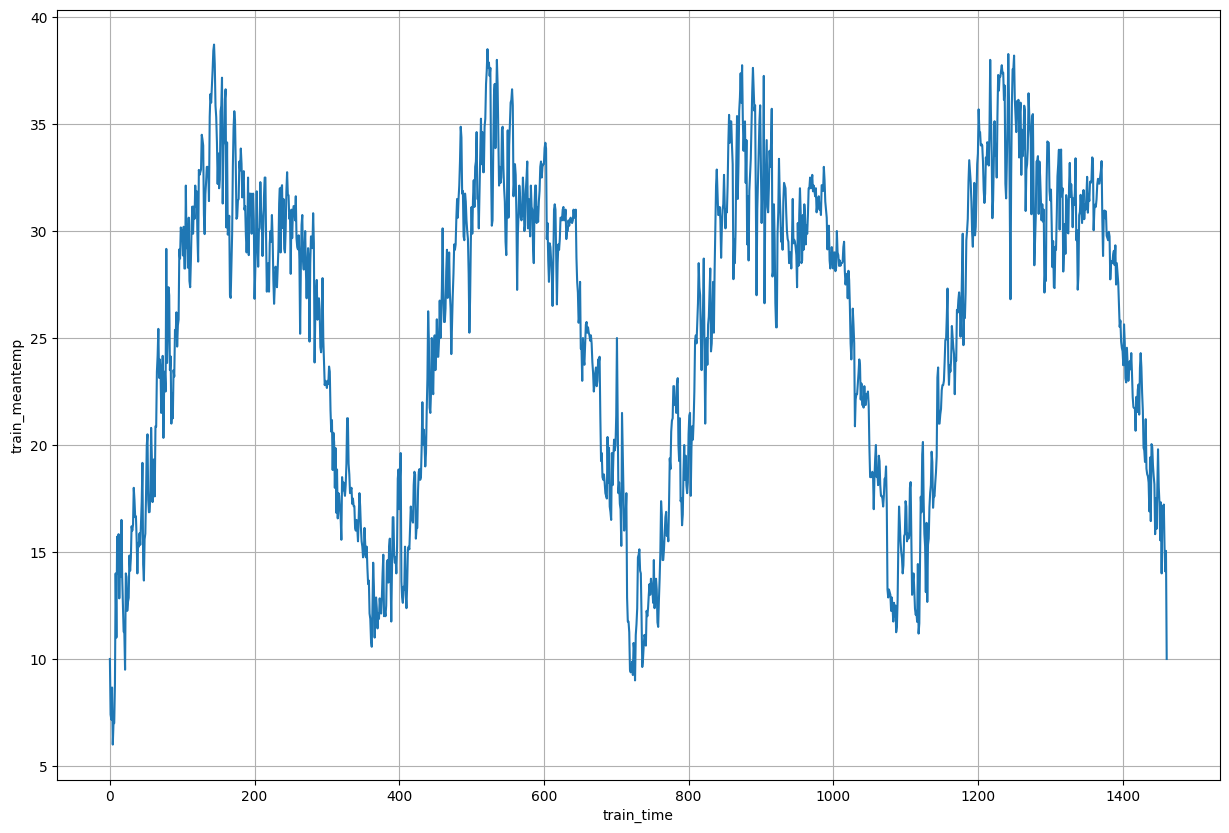

In [6]:
import matplotlib.pyplot as plt

plot_series(time_step,meantemp, xlabel='train_time', ylabel='train_meantemp')


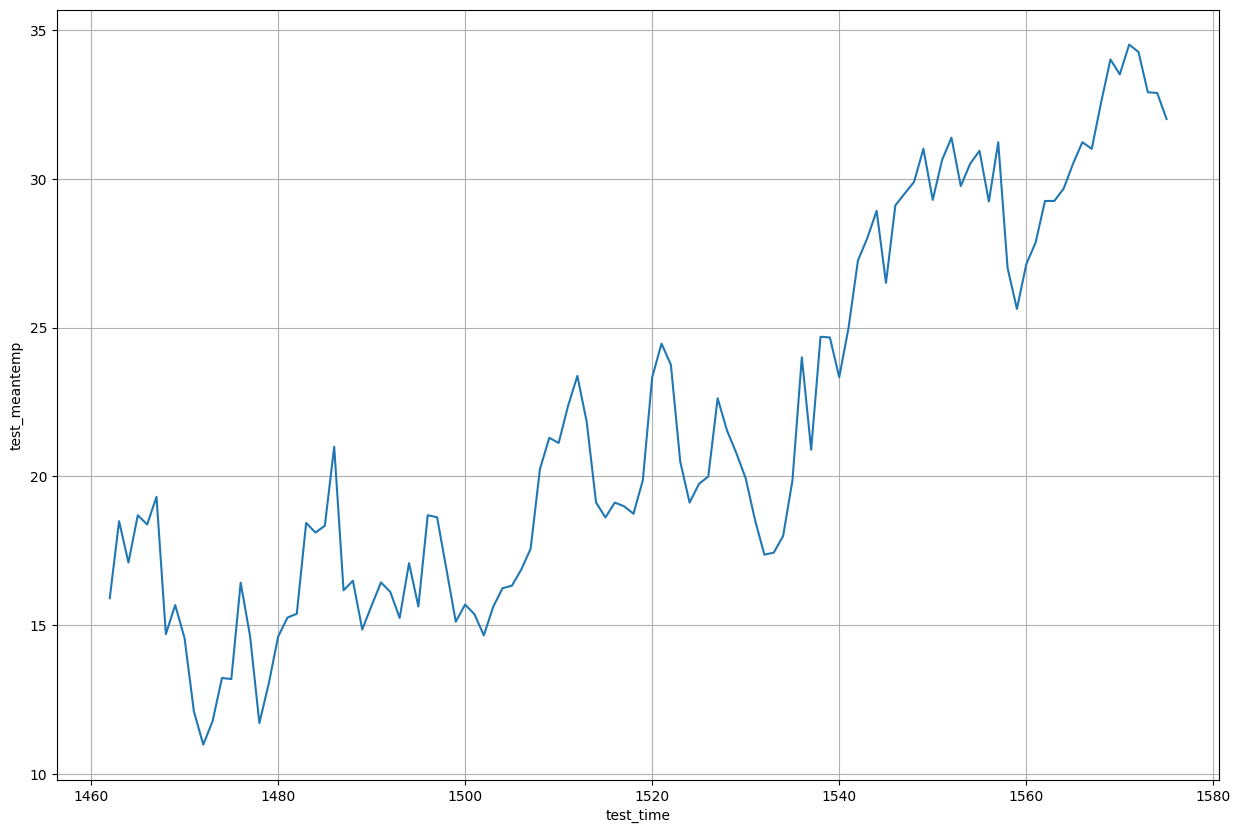

In [7]:
plot_series(valid_x,valid_y, xlabel='test_time', ylabel='test_meantemp')

In [8]:
import tensorflow as tf

# Parameters
window_size = 60
batch_size = 32
shuffle_buffer_size = 1000

# Generate the dataset windows
train_set = windowed_dataset(meantemp, window_size, batch_size, shuffle_buffer_size)
test_set = windowed_dataset(valid_y, window_size, batch_size, shuffle_buffer_size)

In [9]:
# Build the Model
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(window_size,1)),
    tf.keras.layers.Conv1D(filters=64, kernel_size=3,
                      strides=1,
                      activation="relu",
                      padding='causal'),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(30, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Lambda(lambda x: x * 100)
])

 # Print the model summary 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 60, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 60, 64)              │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 30)                  │           1,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             310 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              11 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,191 (203.87 KB)

 Trainable params: 52,191 (203.87 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
init_weights = model.get_weights()

lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-8 * 10**(epoch / 20))


optimizer = tf.keras.optimizers.SGD(momentum=0.9)
loss=tf.keras.losses.Huber()


model.compile(loss=loss, optimizer=optimizer)

# Train the model
history = model.fit(train_set, epochs=100, callbacks=[lr_schedule])

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 29.1659 - learning_rate: 1.0000e-08
Epoch 2/100
19/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 28.7050

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 27.7267 - learning_rate: 1.1220e-08
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25.9008 - learning_rate: 1.2589e-08
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 23.7129 - learning_rate: 1.4125e-08
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 20.9383 - learning_rate: 1.5849e-08
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17.1067 - learning_rate: 1.7783e-08
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11.8679 - learning_rate: 1.9953e-08
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.8665 - learning_rate: 2.2387e-08
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.5263 - learning_rate: 2.5119e-08
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.3483 - learning_rate: 2.8184e-08
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.1609 - learning_rate: 3.1623e-08
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step -

(1e-08, 0.001, 0.0, 100.0)

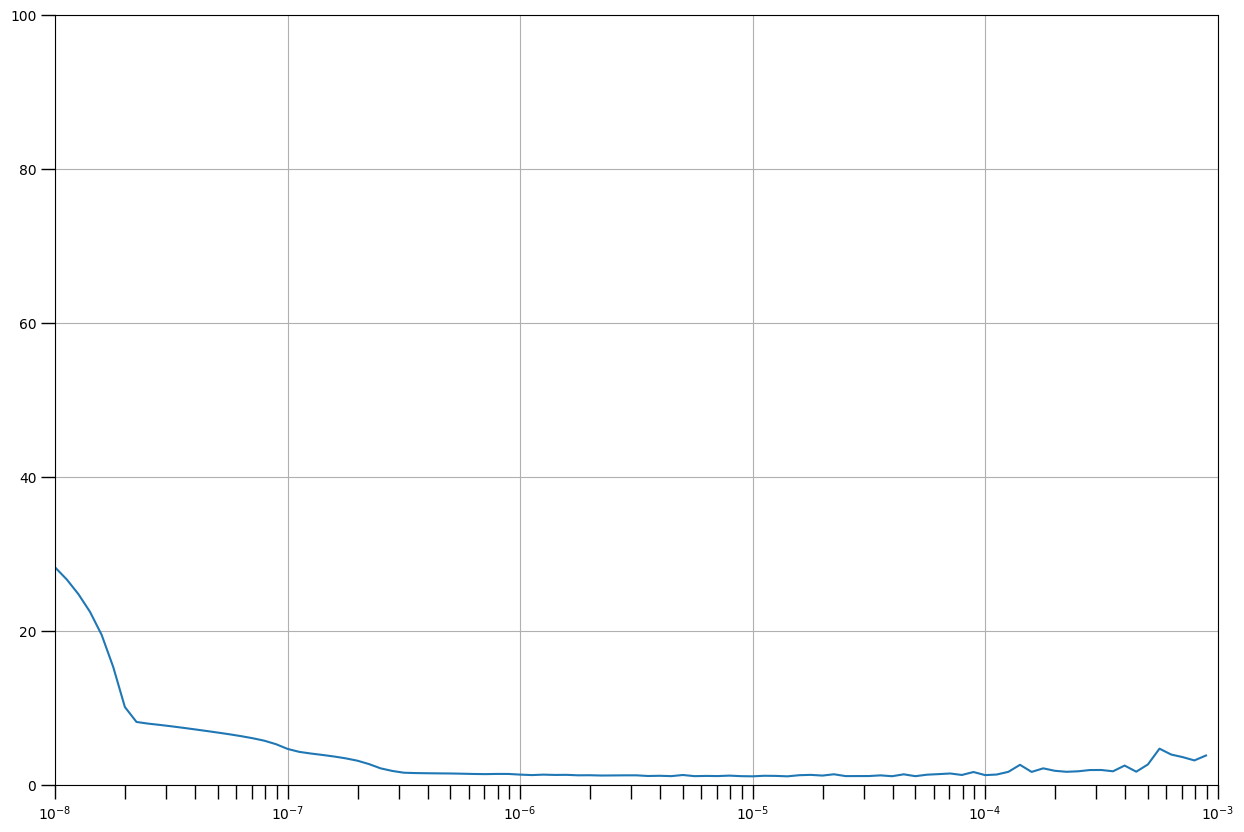

In [11]:
import numpy as np

# Define the learning rate array
lrs = 1e-8 * (10 ** (np.arange(100) / 20))

# Set the figure size
plt.figure(figsize=(15, 10))

# Set the grid
plt.grid(True)

# Plot the loss in log scale
plt.semilogx(lrs, history.history["loss"])

# Increase the tickmarks size
plt.tick_params('both', length=10, width=1, which='both')

# Set the plot boundaries
plt.axis([1e-8, 1e-3, 0, 100])

In [12]:
tf.keras.backend.clear_session()

# Reset the weights
model.set_weights(init_weights)

# Set the learning rate
learning_rate = 1e-5

# Set the optimizer 
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

# Set the training parameters
model.compile(loss=tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])

In [13]:
history = model.fit(train_set,epochs=200)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 11.7531 - mae: 12.2374
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.0129 - mae: 3.4799
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6982 - mae: 2.1459
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.4363 - mae: 1.8783
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1613 - mae: 1.5918
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0671 - mae: 1.4927
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0262 - mae: 1.4489
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0027 - mae: 1.4247
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9871 - mae: 1.4089
Epoch 10/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9752 - mae: 1.3960
Epoch 11/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9639 - mae: 1.3840
Epoch 12/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9520 - mae: 1.3715
Epoch 13/200
44/44 ━━━━

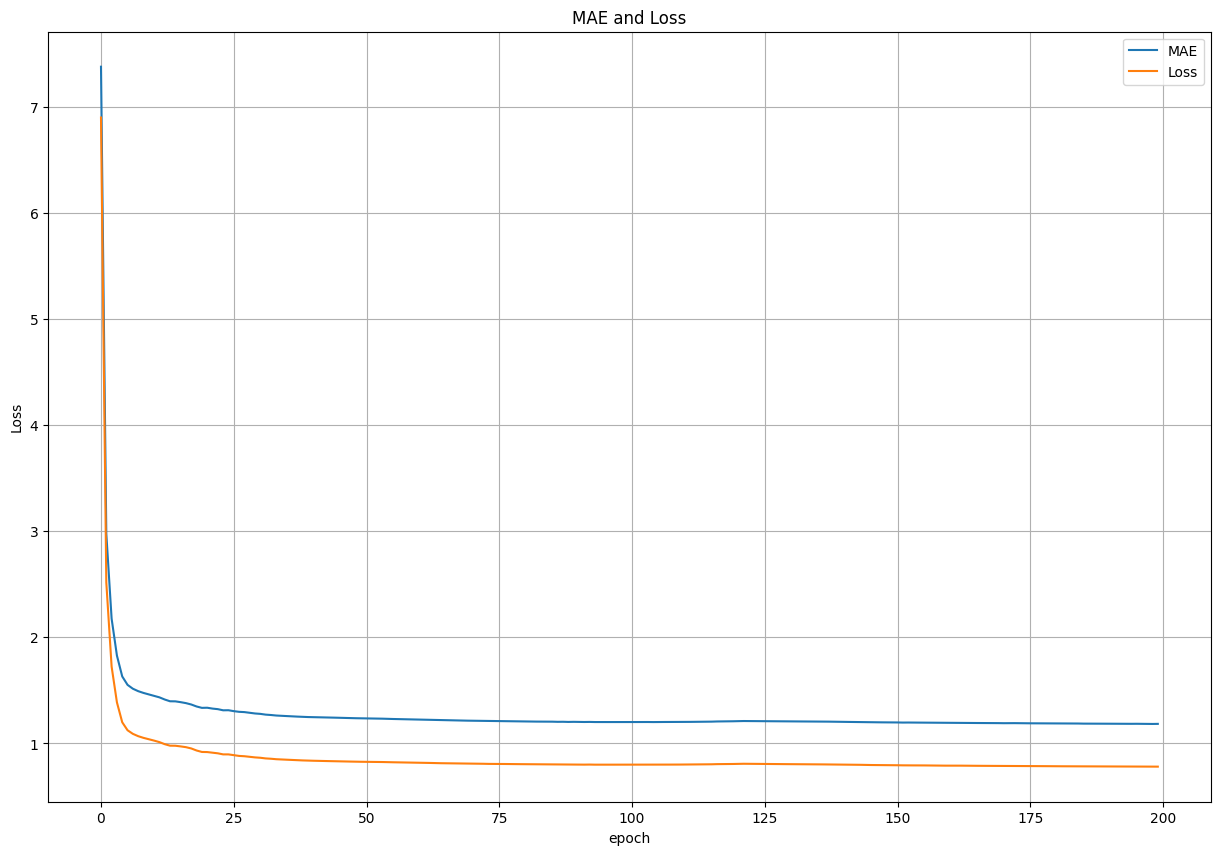

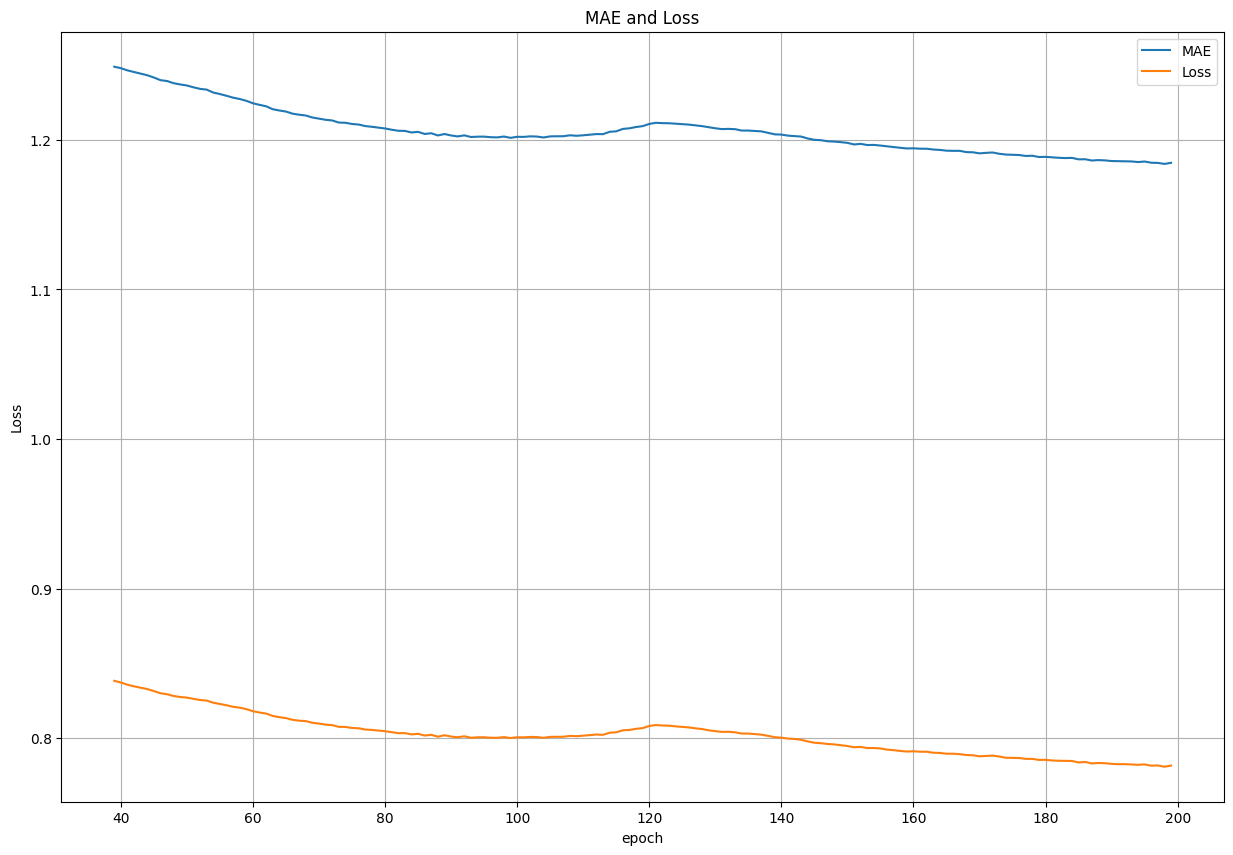

In [14]:
# Get mae and loss from history log
mae=history.history['mae']
loss=history.history['loss']

# Get number of epochs
epochs=range(len(loss)) 

# Plot mae and loss
plot_series(
    x=epochs, 
    y=(mae, loss), 
    title='MAE and Loss', 
    xlabel='epoch',
    ylabel='Loss',
    legend=['MAE', 'Loss']
    )

# Only plot the last 80% of the epochs
zoom_split = int(epochs[-1] * 0.2)
epochs_zoom = epochs[zoom_split:]
mae_zoom = mae[zoom_split:]
loss_zoom = loss[zoom_split:]

# Plot zoomed mae and loss
plot_series(
    x=epochs_zoom, 
    y=(mae_zoom, loss_zoom), 
    title='MAE and Loss', 
    xlabel='epoch',
    ylabel='Loss',
    legend=['MAE', 'Loss']
    )

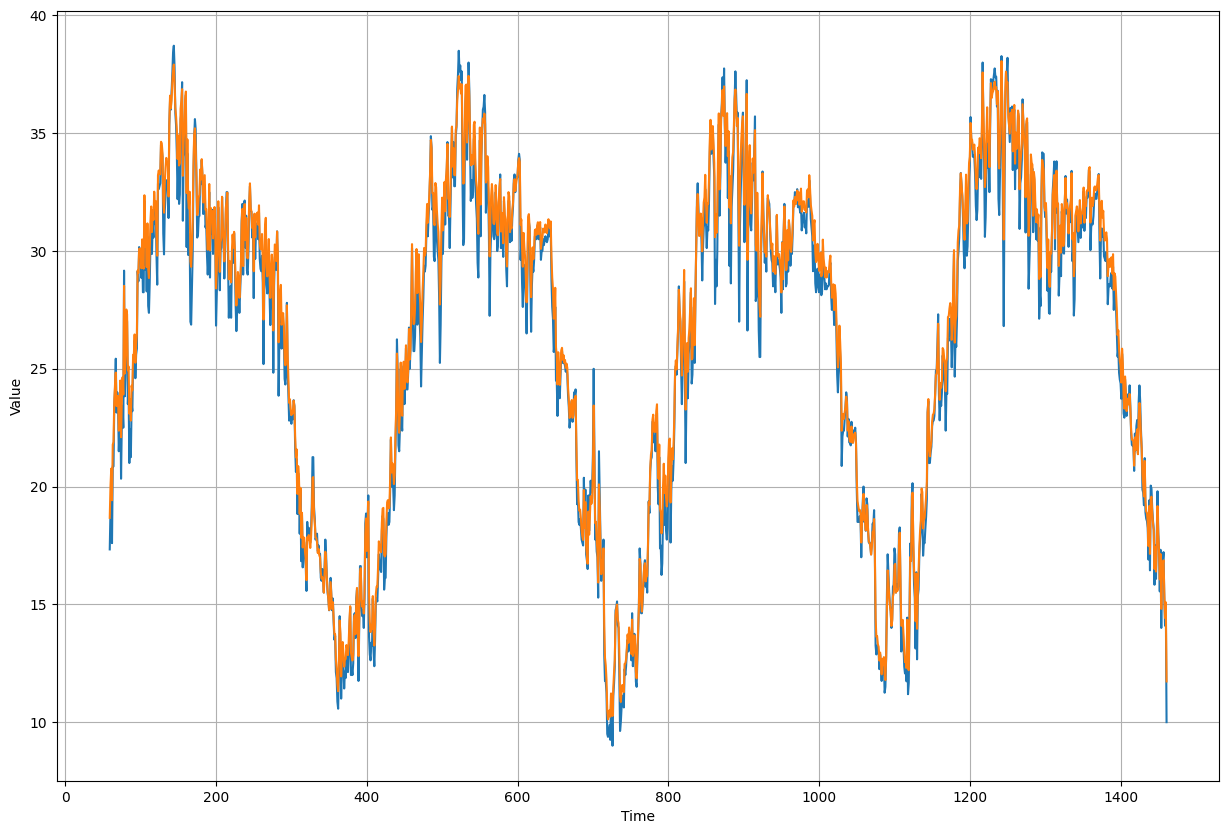

In [15]:
# Reduce the original series
forecast_series = meantemp

# Use helper function to generate predictions
forecast = model_forecast(model, forecast_series, window_size, batch_size)

# Drop single dimensional axis
results = forecast.squeeze()
plot_series(time_step[window_size-1:],(meantemp[window_size-1:],results), xlabel='Time', ylabel='Value')

mae_all=tf.keras.metrics.mae(meantemp[window_size-1:], results).numpy()



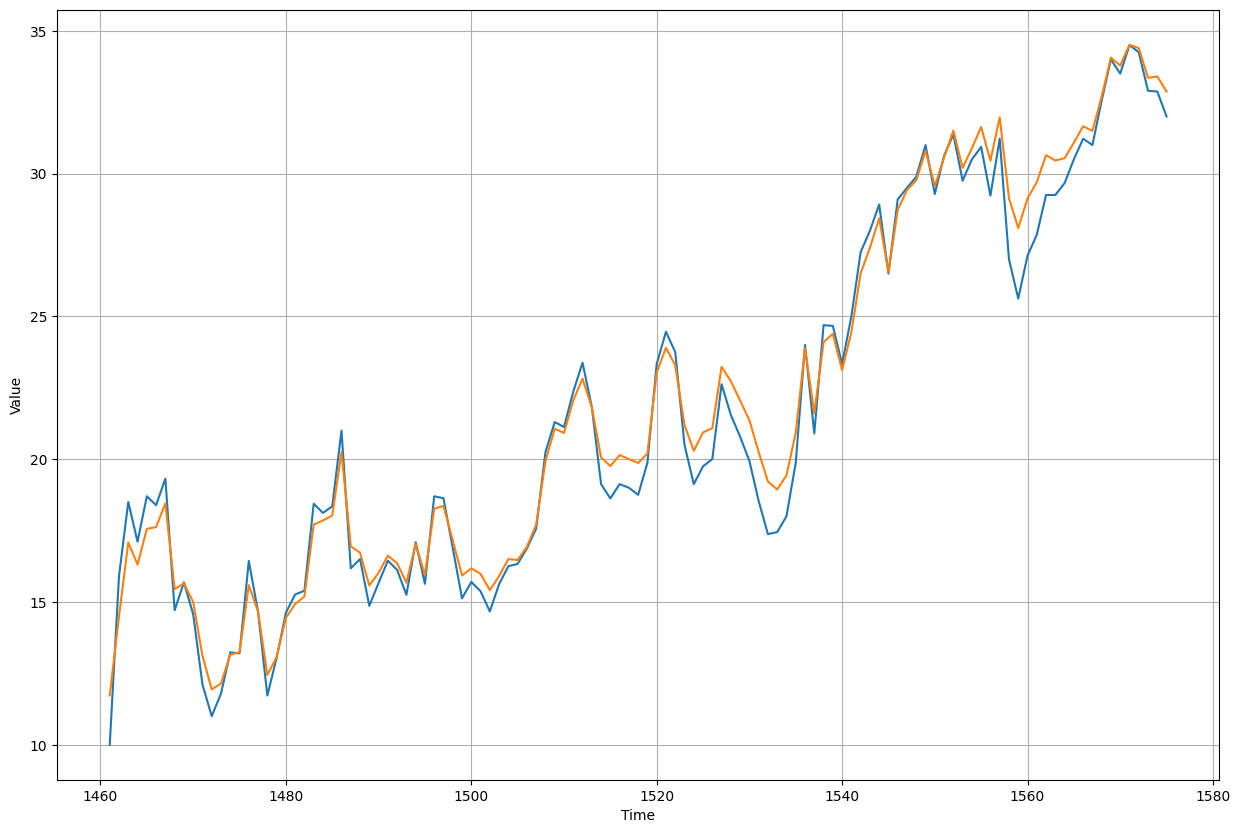

In [16]:
# Reduce the original series
forecast_series = all_meantemp

# Use helper function to generate predictions
forecast = model_forecast(model, forecast_series, window_size, batch_size)

# Drop single dimensional axis
results = forecast.squeeze()

# Plot the results

plot_series(all_time[-115:],(forecast_series[-115:],results[-115:]), xlabel='Time', ylabel='Value')

valid_y_np = valid_y.to_numpy()
mae_test=tf.keras.metrics.mae(valid_y_np, results[-114:]).numpy()

In [17]:
print(f'MAE for all the dataset: {mae_all}')
print(f'MAE for the validation dataset: {mae_test}')

MAE for all the dataset: 0.6074643731117249
MAE for the validation dataset: 0.6298428177833557
